# SD063: Vessel mounted Accoustic Doppler Current Profiler (VMADCP)

## Load required modules

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

## User settings

In [2]:
# 'os150nb' or 'os75nb'
adcp = 'os75nb'

system = 'mac'
if system == 'mac':
    path_server = (
        "/volumes/leg/system/adcp_teledyne_ocean_surveyor/" +
        "acquisition/uhdas/data/SD063_part2/proc/")
elif system == 'windows':
    path_server = (
        "/volumes/leg/system/adcp_teledyne_ocean_surveyor/" +
        "acquisition/uhdas/data/SD063_part2/proc/")
    
nc_path = Path(f"/{path_server}{adcp}/contour/{adcp}.nc")

# Time window (inclusive). Use ISO strings or leave "" to use the dataset range.
# Examples: "2012-06-02", "2012-06-02 12:00", "2012-06-03T18:30"
start_time = "2026-07-21 15:00:00"   # e.g., "2012-06-02"
end_time = ""   # e.g., "2012-06-03 12:00"


# Maximum depth to plot (None = all)
max_depth_plot = 750    # e.g. 500

# Highest-definition: do NOT interpolate time
time_interp_mode = "none"   # "none" | "auto" | "minutes"
target_points = 500         # (unused if "none")
interp_minutes = 2          # (unused if "none")

# Save figures
save_figs = False
dpi = 300                   # high-DPI PNG
also_save_pdf = False        # vector copy for print
title_text = f"VMADCP data from {adcp}"


## Load data

In [3]:
ds = xr.open_dataset(nc_path, decode_cf=True)

def clean(da):
    # replace missing value with NaN
    mv = da.attrs.get("missing_value", None)
    if mv is not None:
        da = da.where(da != mv)
    da = da.where(np.abs(da) < 1e37)
    return da

# check if requested variables are in dataset and replace missing
# value with NaN
for v in ["u", "v", "depth", "uship", "vship", "lon", "lat", "pg"]:
    if v not in ds:
        raise KeyError(f"Variable '{v}' not found in dataset")
    ds[v] = clean(ds[v])

# specific cleanup for variable "Percent Good" (pg)
ds['pg'] = ds.pg.where(ds.pg >= 0)

In [4]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:                 (time: 1480, depth_cell: 60, num_configs: 5)
Coordinates:
  * time                    (time) datetime64[ns] 12kB 2026-07-21T10:19:08.00...
Dimensions without coordinates: depth_cell, num_configs
Data variables: (12/22)
    lon                     (time) float64 12kB -22.52 -22.52 ... -32.6 -32.6
    lat                     (time) float64 12kB 64.0 64.0 64.0 ... 67.66 67.66
    depth                   (time, depth_cell) float32 355kB 52.93 ... 997.0
    u                       (time, depth_cell) float32 355kB nan nan ... nan nan
    v                       (time, depth_cell) float32 355kB nan nan ... nan nan
    amp                     (time, depth_cell) float32 355kB ...
    ...                      ...
    transducer_depth        (num_configs) float32 20B ...
    depth_bin_length        (num_configs) float32 20B ...
    pulse_length            (num_configs) float32 20B ...
    blank_length            (num_configs) float32 20B ...
    ping_interval           (num_configs) float32 20B ...
    transducer_orientation  (num_configs) float32 20B ...
Attributes: (12/23)
    history:                       Created: 2026-07-26 13:34:28 UTC
    Conventions:                   COARDS CF-1.8
    software:                      pycurrents
    hg_changeset:                  3520:6f66c9228769
    title:                         Shipboard ADCP velocity profiles
    summary:                       Shipboard ADCP velocity profiles from SD06...
    ...                            ...
    geospatial_vertical_min:       52.93
    geospatial_vertical_max:       996.97
    geospatial_vertical_units:     m
    geospatial_vertical_positive:  down
    CODAS_variables:               \nVariables in this CODAS short-form Netcd...
    CODAS_processing_note:         \nCODAS processing note:\n================...

## Rotate u and v from VMADCP into along- and across-track velocity using ship's heading

In [5]:
# ships's heading in degrees
heading = (np.degrees(np.arctan2(ds.uship, ds.vship)) + 360) % 360

# ships's heading in radians
theta = np.deg2rad(heading)

along_vel = ds.u * np.sin(theta) + ds.v * np.cos(theta)
across_vel = ds.u * np.cos(theta) - ds.v * np.sin(theta)

# add to dataset
heading.attrs = {'long_name': 'Ship heading',
                 'units': 'degrees'}
ds['heading_ship'] = heading
along_vel.attrs = {'long_name': 'Along-track velocity from VMADCP',
                   'units': 'meter second-1'}
ds['along_vel'] = along_vel
across_vel.attrs = {'long_name': 'Across-track velocity from VMADCP',
                   'units': 'meter second-1'}
ds['across_vel'] = across_vel

## Select time

In [6]:
def parse_time(s):
    return None if (not s or s.strip() == "") else np.datetime64(s)

t0 = parse_time(start_time) or ds.time.min().values
t1 = parse_time(end_time)   or ds.time.max().values
ds = ds.sel(time=slice(t0, t1))
if ds.sizes.get("time", 0) < 2:
    raise ValueError("No (or insufficient) data in selected time window")

## Add along-track distance to dataset

In [7]:
def distance(origin, destination):
    lat1, lon1 = origin
    lat2, lon2 = destination
    radius = 6371 # km

    dlat = math.radians(lat2-lat1)
    dlon = math.radians(lon2-lon1)
    a = math.sin(dlat/2) * math.sin(dlat/2) + math.cos(math.radians(lat1)) \
        * math.cos(math.radians(lat2)) * math.sin(dlon/2) * math.sin(dlon/2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    d = radius * c

    return d

# Quick check: sections of U, V, Percent good, and ships speed plotted against time

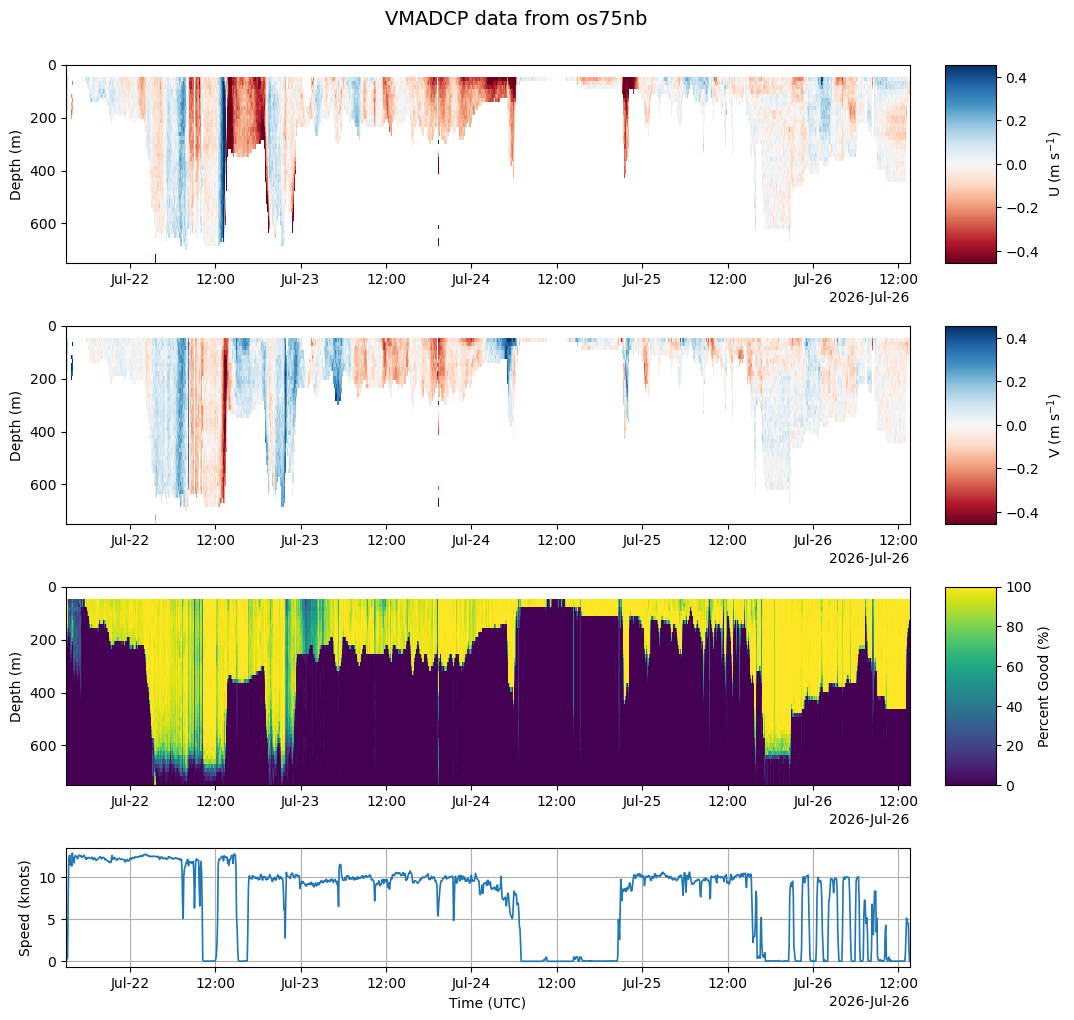

In [8]:
fig = plt.figure(figsize=(12, 11))
gs = fig.add_gridspec(
    nrows=4, ncols=2,
    width_ratios=[1.0, 0.06],
    height_ratios=[1.0, 1.0, 1.0, 0.6],
    hspace=0.35, wspace=0.08
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax_pg = fig.add_subplot(gs[2, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[3, 0], sharex=ax1)

cax1 = fig.add_subplot(gs[0, 1])
cax2 = fig.add_subplot(gs[1, 1])
cax3 = fig.add_subplot(gs[2, 1])

y_depth = ds.depth.median('time')


# U
v_max = np.abs(ds.u).quantile(0.98)
pcm1 = ax1.pcolormesh(ds.time, y_depth, ds.u.transpose(),
                      cmap="RdBu", vmin=-v_max, vmax=v_max,
                      shading="nearest")
ax1.set_ylim(max_depth_plot, 0)
ax1.set_ylabel("Depth (m)")
cb1 = fig.colorbar(pcm1, cax=cax1)
cb1.set_label("U (m s$^{-1}$)")

# V
np.abs(ds.v).quantile(0.98)
pcm2 = ax2.pcolormesh(ds.time, y_depth, ds.v.transpose(),
                      cmap="RdBu", vmin=-v_max, vmax=v_max,
                      shading="nearest")
ax2.set_ylim(max_depth_plot, 0)
ax2.set_ylabel("Depth (m)")
cb2 = fig.colorbar(pcm2, cax=cax2)
cb2.set_label("V (m s$^{-1}$)")

# PG (coolwarm)
pcm3 = ax_pg.pcolormesh(ds.time, y_depth, ds.pg.transpose(),
                        vmin=0, vmax=100, shading="nearest")
ax_pg.set_ylim(max_depth_plot, 0)
ax_pg.set_ylabel("Depth (m)")
cb3 = fig.colorbar(pcm3, cax=cax3)
cb3.set_label("Percent Good (%)")

# Ship speed
spd_kn = (np.sqrt(ds.uship**2 + ds.vship**2) * 1.943844)

ax3.plot(ds.time, spd_kn, lw=1.2)
ax3.set_ylabel("Speed (knots)")
ax3.set_xlabel("Time (UTC)")
ax3.grid(True)

# Time formatting
locator = mdates.AutoDateLocator()
fmt = mdates.ConciseDateFormatter(locator)
for ax in (ax1, ax2, ax_pg, ax3):
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(fmt)
    ax.set_xlim(np.datetime64(t0), np.datetime64(t1))

if max_depth_plot is not None:
    for ax in (ax1, ax2, ax_pg):
        ax.set_ylim(float(max_depth_plot), 0)

fig.suptitle(title_text, y=0.98, fontsize=14)
plt.subplots_adjust(top=0.93)

if save_figs:
    fig.savefig(nc_path.with_name("sections.png"), dpi=dpi)
    if also_save_pdf:
        fig.savefig(nc_path.with_name("sections.pdf"))

plt.show()

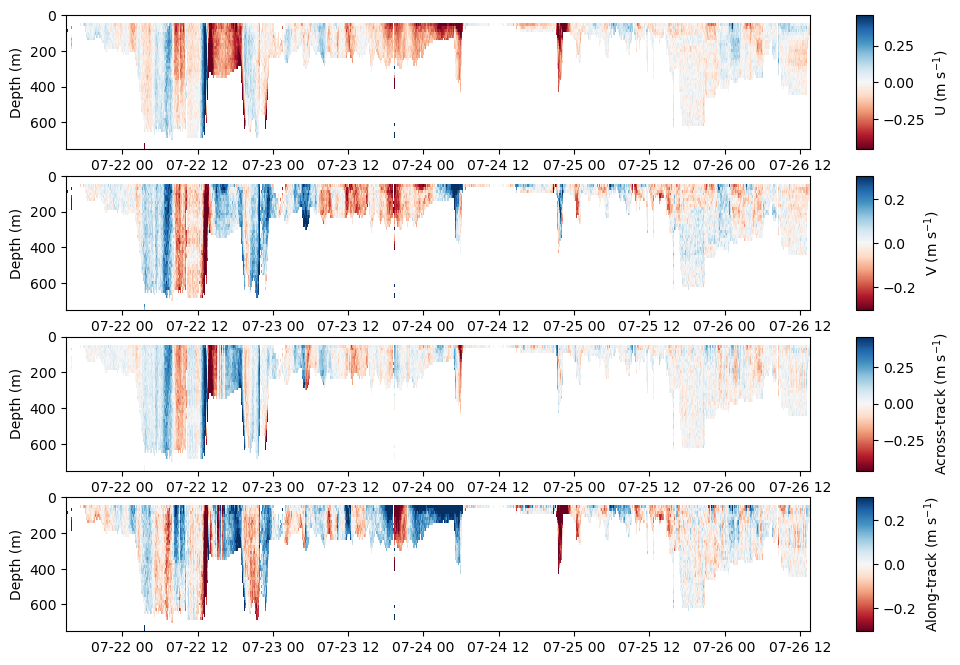

In [9]:
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
# U
v_max = np.abs(ds.u).quantile(0.98)
pc = plt.pcolormesh(ds.time, y_depth, ds.u.transpose(),
                      cmap="RdBu", vmin=-v_max, vmax=v_max,
                      shading="nearest")
plt.ylim(max_depth_plot, 0)
plt.ylabel("Depth (m)")
cb1 = plt.colorbar(pc, aspect=8)
cb1.set_label("U (m s$^{-1}$)")

plt.subplot(4, 1, 2)
# V
v_max = np.abs(ds.v).quantile(0.98)
pc = plt.pcolormesh(ds.time, y_depth, ds.v.transpose(),
                      cmap="RdBu", vmin=-v_max, vmax=v_max,
                      shading="nearest")
plt.ylim(max_depth_plot, 0)
plt.ylabel("Depth (m)")
cb1 = plt.colorbar(pc, aspect=8)
cb1.set_label("V (m s$^{-1}$)")

plt.subplot(4, 1, 3)
# Across-track
v_max = np.abs(ds.u).quantile(0.98)
pc = plt.pcolormesh(ds.time, y_depth, ds.across_vel.transpose(),
                      cmap="RdBu", vmin=-v_max, vmax=v_max,
                      shading="nearest")
plt.ylim(max_depth_plot, 0)
plt.ylabel("Depth (m)")
cb1 = plt.colorbar(pc, aspect=8)
cb1.set_label("Across-track (m s$^{-1}$)")

plt.subplot(4, 1, 4)
# Along-track
v_max = np.abs(ds.v).quantile(0.98)
pc = plt.pcolormesh(ds.time, y_depth, ds.along_vel.transpose(),
                      cmap="RdBu", vmin=-v_max, vmax=v_max,
                      shading="nearest")
plt.ylim(max_depth_plot, 0)
plt.ylabel("Depth (m)")
cb1 = plt.colorbar(pc, aspect=8)
cb1.set_label("Along-track (m s$^{-1}$)")

# Time formatting
locator = mdates.AutoDateLocator()
fmt = mdates.ConciseDateFormatter(locator)
for ax in (ax1, ax2, ax_pg, ax3):
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(fmt)
    ax.set_xlim(np.datetime64(t0), np.datetime64(t1))

In [27]:
ds

<xarray.Dataset> Size: 689kB
Dimensions:                 (time: 524, depth_cell: 60, num_configs: 2)
Coordinates:
  * time                    (time) datetime64[ns] 4kB 2026-07-21T15:04:01 ......
Dimensions without coordinates: depth_cell, num_configs
Data variables: (12/25)
    lon                     (time) float64 4kB -22.52 -22.52 ... -32.7 -32.73
    lat                     (time) float64 4kB 64.0 64.0 64.0 ... 65.55 65.55
    depth                   (time, depth_cell) float32 126kB 52.93 ... 997.0
    u                       (time, depth_cell) float32 126kB 0.005983 ... nan
    v                       (time, depth_cell) float32 126kB 0.01027 ... nan
    amp                     (time, depth_cell) float32 126kB ...
    ...                      ...
    blank_length            (num_configs) float32 8B ...
    ping_interval           (num_configs) float32 8B ...
    transducer_orientation  (num_configs) float32 8B ...
    heading_ship            (time) float32 2kB 342.6 35.41 35.25 ... 255.3 251.7
    along_vel               (time) float32 2kB 0.04011 0.1413 ... 4.677 4.721
    across_vel              (time) float32 2kB -1.118e-08 ... -4.768e-07
Attributes: (12/23)
    history:                       Created: 2026-07-23 10:39:30 UTC
    Conventions:                   COARDS CF-1.8
    software:                      pycurrents
    hg_changeset:                  3520:6f66c9228769
    title:                         Shipboard ADCP velocity profiles
    summary:                       Shipboard ADCP velocity profiles from SD06...
    ...                            ...
    geospatial_vertical_min:       52.93
    geospatial_vertical_max:       996.95
    geospatial_vertical_units:     m
    geospatial_vertical_positive:  down
    CODAS_variables:               \nVariables in this CODAS short-form Netcd...
    CODAS_processing_note:         \nCODAS processing note:\n================...

## to do

calculate heading for each time step and rotate u and v into along track and across track velocity

new axis: along-track distance

bin everything in "100m" (along-track mean)

add "stars" where ship was stationary

sections (distance-depth) of along-track velocity and across-track velocity

several maps with arrows of velocity at e.g. "surface", 100m, 300m, bottom


# Ignore the below

## Optional: time interpolation

In [5]:
def build_time_grid(time, mode):
    if mode == "none":
        return None
    tmin = time.values[0].astype("datetime64[s]")
    tmax = time.values[-1].astype("datetime64[s]")
    if tmax <= tmin:
        return None
    if mode == "minutes":
        step = np.timedelta64(int(interp_minutes * 60), "s")
    elif mode == "auto":
        dur = (tmax - tmin) / np.timedelta64(1, "s")
        step = np.timedelta64(int(max(dur / max(target_points, 2), 1)), "s")
    else:
        return None
    return np.arange(tmin, tmax + step, step).astype("datetime64[ns]")

new_time = build_time_grid(ds.time, time_interp_mode)

# ds2 for sections (possibly interpolated, but here "none"); ds native for map
if new_time is not None:
    ds2 = ds[["u", "v", "depth", "uship", "vship", "pg"]].interp(time=new_time)
    time_plot = ds2.time
else:
    ds2 = ds
    time_plot = ds.time

In [15]:
ds

<xarray.Dataset> Size: 230kB
Dimensions:                 (time: 211, depth_cell: 50, num_configs: 1)
Coordinates:
  * time                    (time) datetime64[ns] 2kB 2026-07-21T15:03:59 ......
Dimensions without coordinates: depth_cell, num_configs
Data variables: (12/22)
    lon                     (time) float64 2kB -22.52 -22.52 ... -29.9 -29.94
    lat                     (time) float64 2kB 64.0 64.0 64.0 ... 65.08 65.08
    depth                   (time, depth_cell) float32 42kB 18.97 ... 411.0
    u                       (time, depth_cell) float32 42kB -0.04454 ... -0.1037
    v                       (time, depth_cell) float32 42kB 0.1481 ... -0.08612
    amp                     (time, depth_cell) float32 42kB ...
    ...                      ...
    transducer_depth        (num_configs) float32 4B ...
    depth_bin_length        (num_configs) float32 4B ...
    pulse_length            (num_configs) float32 4B ...
    blank_length            (num_configs) float32 4B ...
    ping_interval           (num_configs) float32 4B ...
    transducer_orientation  (num_configs) float32 4B ...
Attributes: (12/23)
    history:                       Created: 2026-07-22 08:34:17 UTC
    Conventions:                   COARDS CF-1.8
    software:                      pycurrents
    hg_changeset:                  3520:6f66c9228769
    title:                         Shipboard ADCP velocity profiles
    summary:                       Shipboard ADCP velocity profiles from SD06...
    ...                            ...
    geospatial_vertical_min:       18.97
    geospatial_vertical_max:       410.97
    geospatial_vertical_units:     m
    geospatial_vertical_positive:  down
    CODAS_variables:               \nVariables in this CODAS short-form Netcd...
    CODAS_processing_note:         \nCODAS processing note:\n================...

/var/folders/92/f0b4psrx4lq3cpnp6r40jm4w0000gr/T/ipykernel_1013/63273483.py:1: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(ds.lon, ds.depth.median('time'), ds.u.transpose(), shading='nearest')


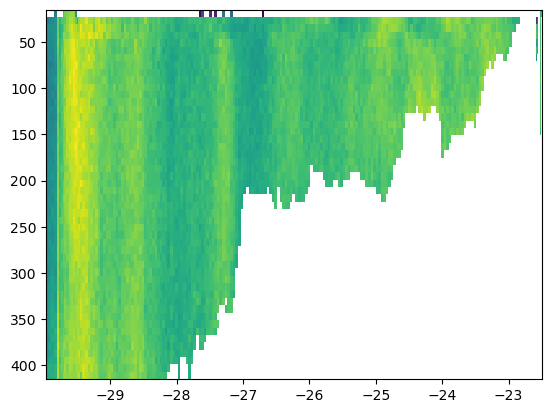

In [22]:
plt.pcolormesh(ds.lon, ds.depth.median('time'), ds.u.transpose(), shading='nearest')
plt.gca().invert_yaxis()

## Prepare sections

In [12]:
depth2 = ds2["depth"].values
y_depth = np.nanmedian(depth2, axis=0).astype(float)

In [14]:
ds2.depth.median('time')

<xarray.DataArray 'depth' (depth_cell: 50)> Size: 200B
array([ 18.97,  26.97,  34.97,  42.97,  50.97,  58.97,  66.97,  74.97,
        82.97,  90.97,  98.97, 106.97, 114.97, 122.97, 130.97, 138.97,
       146.97, 154.97, 162.97, 170.97, 178.97, 186.97, 194.97, 202.97,
       210.97, 218.97, 226.97, 234.97, 242.97, 250.97, 258.97, 266.97,
       274.97, 282.97, 290.97, 298.97, 306.97, 314.97, 322.97, 330.97,
       338.97, 346.97, 354.97, 362.97, 370.97, 378.97, 386.97, 394.97,
       402.97, 410.97], dtype=float32)
Dimensions without coordinates: depth_cell
Attributes:
    long_name:  Depth
    units:      meter
    C_format:   %8.2f
    data_min:   18.97
    data_max:   410.97

In [13]:
y_depth

array([ 18.96999931,  26.96999931,  34.97000122,  42.97000122,
        50.97000122,  58.97000122,  66.97000122,  74.97000122,
        82.97000122,  90.97000122,  98.97000122, 106.97000122,
       114.97000122, 122.97000122, 130.97000122, 138.97000122,
       146.97000122, 154.97000122, 162.97000122, 170.97000122,
       178.97000122, 186.97000122, 194.97000122, 202.97000122,
       210.97000122, 218.97000122, 226.97000122, 234.97000122,
       242.97000122, 250.97000122, 258.97000122, 266.97000122,
       274.97000122, 282.97000122, 290.97000122, 298.97000122,
       306.97000122, 314.97000122, 322.97000122, 330.97000122,
       338.97000122, 346.97000122, 354.97000122, 362.97000122,
       370.97000122, 378.97000122, 386.97000122, 394.97000122,
       402.97000122, 410.97000122])

In [6]:
depth2 = ds2["depth"].values
y_depth = np.nanmedian(depth2, axis=0).astype(float)

keep_cols = np.isfinite(y_depth)
y_depth = y_depth[keep_cols]
u = ds2["u"].values[:, keep_cols]
v = ds2["v"].values[:, keep_cols]
pg = ds2["pg"].values[:, keep_cols]

order = np.argsort(y_depth)
y_depth = y_depth[order]
u = u[:, order]
v = v[:, order]
pg = pg[:, order]

if max_depth_plot is not None:
    sel = y_depth <= float(max_depth_plot)
    y_depth = y_depth[sel]
    u = u[:, sel]
    v = v[:, sel]
    pg = pg[:, sel]

if y_depth.size == 0:
    raise ValueError("No depth bins remain after filtering.")

# PG clipping (0–100)
pg_plot = np.clip(pg, 0, 100)

# U/V color limits
def sym_limits(arr, q=0.98):
    a = arr[np.isfinite(arr)]
    if a.size == 0:
        return (-1.0, 1.0)
    vmax = np.quantile(np.abs(a), q)
    vmax = max(float(vmax), 0.1)
    return (-vmax, vmax)

ulims = sym_limits(u)
vlims = sym_limits(v)

# Ship speed
speed_knots_sections = (np.sqrt(ds2["uship"]**2 + ds2["vship"]**2) * 1.943844).values

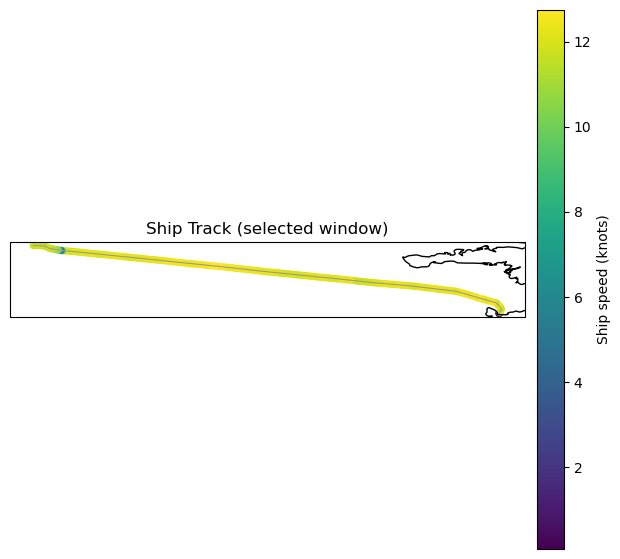

In [8]:
# =========================
# PLOT: SHIP TRACK (colored by native speed)
# =========================
lon = ds["lon"].values
lat = ds["lat"].values
speed_knots_map = (np.sqrt(ds["uship"]**2 + ds["vship"]**2) * 1.943844).values

mask = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(speed_knots_map)
lon_m, lat_m, spd_m = lon[mask], lat[mask], speed_knots_map[mask]

try:
    import cartopy.crs as ccrs
    proj = ccrs.PlateCarree()

    figm = plt.figure(figsize=(8, 7))
    axm = figm.add_subplot(1, 1, 1, projection=proj)
    axm.coastlines()

    sc = axm.scatter(lon_m, lat_m, c=spd_m, cmap="viridis", s=18, transform=proj)
    axm.plot(lon_m, lat_m, color="0.6", lw=0.8, transform=proj)

    cb = figm.colorbar(sc, ax=axm, pad=0.02)
    cb.set_label("Ship speed (knots)")

    axm.set_title("Ship Track (selected window)")
except Exception:
    figm = plt.figure(figsize=(7, 6))
    axm = figm.add_subplot(1, 1, 1)
    sc = axm.scatter(lon_m, lat_m, c=spd_m, cmap="viridis", s=15)
    axm.plot(lon_m, lat_m, color="0.6", lw=0.8)
    cb = figm.colorbar(sc, ax=axm, pad=0.02)
    cb.set_label("Ship speed (knots)")
    axm.set_title("Ship Track (selected window)")
    axm.set_xlabel("Longitude")
    axm.set_ylabel("Latitude")
    axm.set_aspect("equal", adjustable="box")

if save_figs:
    figm.savefig(nc_path.with_name("track.png"), dpi=dpi)
    if also_save_pdf:
        figm.savefig(nc_path.with_name("track.pdf"))

plt.show()